# 📊 Visualisation des Données  

Dans ce notebook, nous analysons et affichons **graphiquement** les caractéristiques des images.  
Nous allons explorer :  
✅ La distribution des **formats d'images**  
✅ L'orientation des **images (portrait/paysage)**  
✅ La répartition des **couleurs dominantes**  


## 📦 Installation des dépendances  
Nous installons `seaborn` pour améliorer la visualisation des données.
```
pip install seaborn
```

## 📸 Distribution des Formats d'Images  
Ce graphique montre combien d'images existent pour chaque format (`JPEG`, `PNG`, etc.).
Cela nous aide à comprendre la diversité des images utilisées.

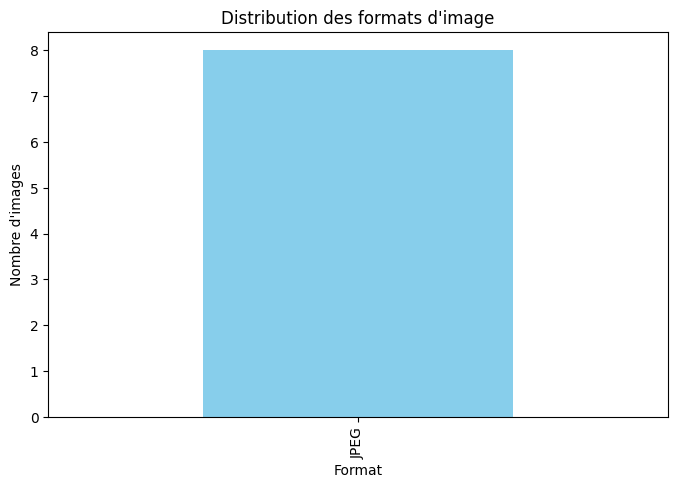

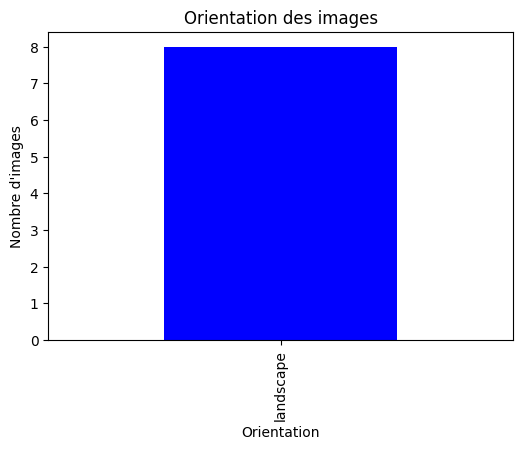

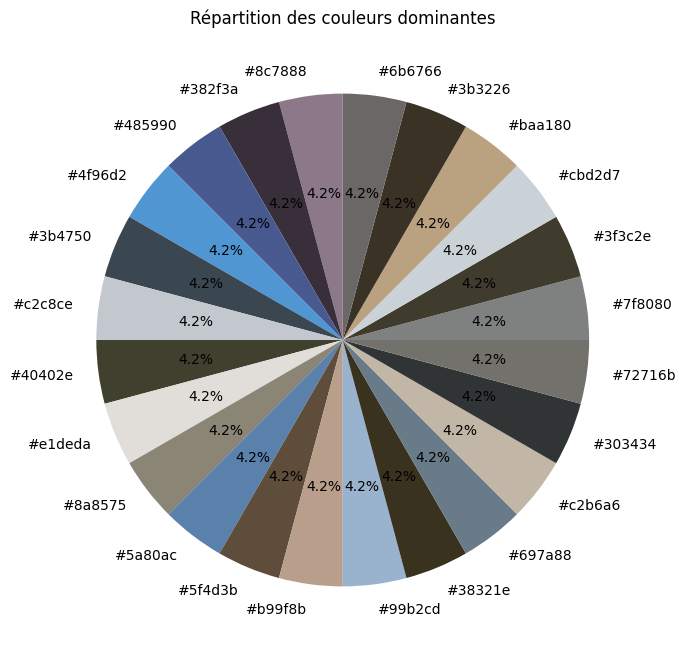

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ANNOTATION_FILE = "annotations.json"

with open(ANNOTATION_FILE, "r") as f:
    data = json.load(f)

df = pd.DataFrame([
    {
        "image": img,
        "format": details["metadata"]["format"],
        "size_x": details["metadata"]["size"][0],
        "size_y": details["metadata"]["size"][1],
        "orientation": "portrait" if details["metadata"]["size"][1] > details["metadata"]["size"][0] else "landscape",
        "colors": details["dominant_colors"]
    }
    for img, details in data.items()
])

plt.figure(figsize=(8, 5))
df["format"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Distribution des formats d'image")
plt.xlabel("Format")
plt.ylabel("Nombre d'images")
plt.show()

plt.figure(figsize=(6, 4))
df["orientation"].value_counts().plot(kind="bar", color=["blue", "orange"])
plt.title("Orientation des images")
plt.xlabel("Orientation")
plt.ylabel("Nombre d'images")
plt.show()

color_counts = {}
for colors in df["colors"]:
    for color in colors:
        color_counts[color] = color_counts.get(color, 0) + 1

plt.figure(figsize=(8, 8))
plt.pie(color_counts.values(), labels=color_counts.keys(), colors=color_counts.keys(), autopct='%1.1f%%')
plt.title("Répartition des couleurs dominantes")
plt.show()
